In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "dualtest_experiments" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "DUALTEST"))

print(PROJECT_ROOT)

/home/alumno1/Downloads/NLP_Proyecto_Final-main


In [2]:
import pandas as pd

from calibration import calibrate_1d, calibrate_2d

In [11]:
df_normal = pd.read_csv(
    PROJECT_ROOT / "results/booktection_qwen15_qwen05_n1000.csv"
)

df_adv = pd.read_csv(
    PROJECT_ROOT / "results/generalization_book_qwen15_qwen05.csv"
)

df_normal.shape, df_adv.shape

((1000, 11), (110, 11))

In [12]:
member_scores = df_normal[df_normal["label"] == 1]["p_rlb"].tolist()
nonmember_scores = df_normal[df_normal["label"] == 0]["p_rlb"].tolist()
adversarial_scores = df_adv["p_rlb"].tolist()

rlb_result = calibrate_1d(
    member_scores=member_scores,
    nonmember_scores=nonmember_scores,
    adversarial_scores=adversarial_scores,
    lower_is_suspicious=True,
)

rlb_result

CalibrationResult(threshold=9.699787970056384e-42, recall_normal=0.002, fpr_adversarial=0.0, threshold_2=None)

In [13]:
member_esb = list(zip(
    df_normal[df_normal["label"] == 1]["edit_similarity"],
    df_normal[df_normal["label"] == 1]["p_esb"],
))

nonmember_esb = list(zip(
    df_normal[df_normal["label"] == 0]["edit_similarity"],
    df_normal[df_normal["label"] == 0]["p_esb"],
))

adversarial_esb = list(zip(
    df_adv["edit_similarity"],
    df_adv["p_esb"],
))

esb_result = calibrate_2d(
    member=member_esb,
    nonmember=nonmember_esb,
    adversarial=adversarial_esb,
)

esb_result

CalibrationResult(threshold=7.395427098217873e-23, recall_normal=0.008, fpr_adversarial=0.0, threshold_2=0.3550724637681159)

In [14]:
df_adv.groupby("set")[[
    "run_length",
    "edit_similarity",
    "p_rlb",
    "p_esb"
]].median()

,run_length,edit_similarity,p_rlb,p_esb
set,,,,
A,24.0,0.386913,0.231448,6.374431e-02
B,0.5,0.391667,0.993145,9.663826e-17


In [15]:
df_normal.groupby("label")[[
    "run_length",
    "edit_similarity",
    "p_rlb",
    "p_esb"
]].median()

,run_length,edit_similarity,p_rlb,p_esb
label,,,,
0,0.0,0.265804,1.0,1.724036e-34
1,0.0,0.265037,1.0,1.016962e-38


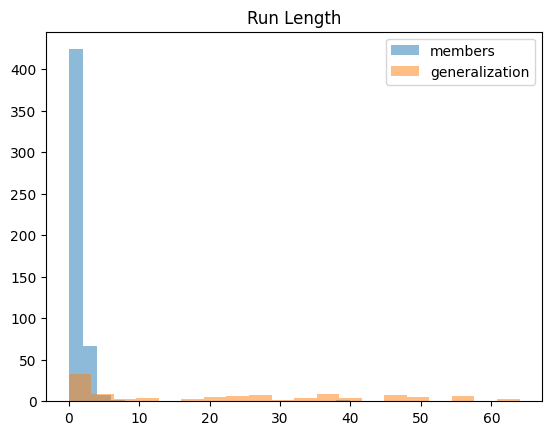

In [16]:
import matplotlib.pyplot as plt

plt.hist(
    df_normal[df_normal.label == 1]["run_length"],
    bins=20,
    alpha=0.5,
    label="members"
)

plt.hist(
    df_adv["run_length"],
    bins=20,
    alpha=0.5,
    label="generalization"
)

plt.legend()
plt.title("Run Length")
plt.show()

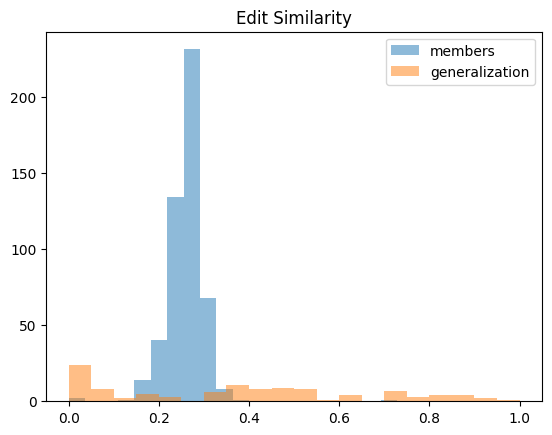

In [17]:
plt.hist(
    df_normal[df_normal.label == 1]["edit_similarity"],
    bins=20,
    alpha=0.5,
    label="members"
)

plt.hist(
    df_adv["edit_similarity"],
    bins=20,
    alpha=0.5,
    label="generalization"
)

plt.legend()
plt.title("Edit Similarity")
plt.show()

In [18]:
df_adv.to_csv(PROJECT_ROOT / "results/generalization_book_qwen15_qwen05.csv", index=False)  
print(df_adv.shape)

(110, 11)


Target: Qwen 1.5B
Reference: Qwen 0.5B

BookTection: n=100
Generalization A: n=100
Generalization B: n=10

Resultado:
- RLB: sin threshold válido
- ESB: recall 6%, FPR adversarial 0%